# 02 — Network analysis

**Purpose:** Describe how familiarity and social networks emerge over 52 weeks, then inspect structure on the representative baseline seed (`outputs/baseline/seed_6400`).

**Sections:** longitudinal growth, cross-sectional summary, degree CCDF, centrality (GCC).


In [10]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().resolve().parent / "analysis"))
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))
from notebook_paths import ensure_src_on_path

PROJECT_ROOT = ensure_src_on_path()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"


## Longitudinal emergence

In [11]:
import pandas as pd
from soulcycle_network.analysis.io import load_master_table

master = load_master_table(OUTPUT_DIR)
cols = [c for c in (
    "week", "network_type", "edges", "gcc_nodes",
    "gcc_average_shortest_path", "average_clustering", "components",
) if c in master.columns]

(
    master[master["scenario"] == "baseline"][cols]
    .groupby(["week", "network_type"], as_index=False)
    .mean(numeric_only=True)
)


,week,network_type,edges,gcc_nodes,gcc_average_shortest_path,average_clustering,components
0,1,familiarity,0.0,0.0,NaN,0.000000,0.0
1,1,social,0.0,0.0,NaN,0.000000,0.0
2,4,familiarity,1.9,2.0,1.000000,0.000000,1.9
3,4,social,0.0,0.0,NaN,0.000000,0.0
4,8,familiarity,10.4,3.4,1.393333,0.000000,7.8
5,8,social,0.1,0.2,1.000000,0.000000,0.1
6,13,familiarity,33.6,6.3,1.919048,0.016223,19.4
7,13,social,1.2,1.5,1.047619,0.000000,1.1
8,26,familiarity,154.1,18.2,2.788116,0.053475,42.9
9,26,social,7.0,3.0,1.316667,0.016667,5.4


## Structure at week 52 (baseline seed 6400)

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from soulcycle_network.analysis.io import familiarity_graph_from_seed, load_seed_exports
from soulcycle_network.analysis.metrics import centrality_table, summarize_graph
from soulcycle_network.analysis.plots import degree_distribution, plot_degree_ccdf

seed_dir = OUTPUT_DIR / "baseline" / "seed_6400"
graph = familiarity_graph_from_seed(seed_dir, include_isolates=True)
summarize_graph(graph)


{'nodes': 10000,
 'edges': 612,
 'connected_nodes': 522,
 'isolates': 9478,
 'components': 9521,
 'density_full_population': 1.224122412241224e-05,
 'average_degree_full_population': 0.1224,
 'mean_degree_population': 0.1224,
 'mean_degree_connected_subgraph': 2.3448275862068964,
 'average_clustering': 0.005320616752528517,
 'transitivity': 0.13695090439276486,
 'degree_assortativity': -0.2472536568637887,
 'gcc_nodes': 60,
 'gcc_edges': 82,
 'gcc_share_of_connected_nodes': 0.11494252873563218,
 'gcc_diameter': 8,
 'gcc_radius': 4,
 'gcc_average_shortest_path': 3.635593220338983,
 'gcc_clustering': 0.1317002442002442,
 'gcc_transitivity': 0.13636363636363635}

## Degree distribution and centrality

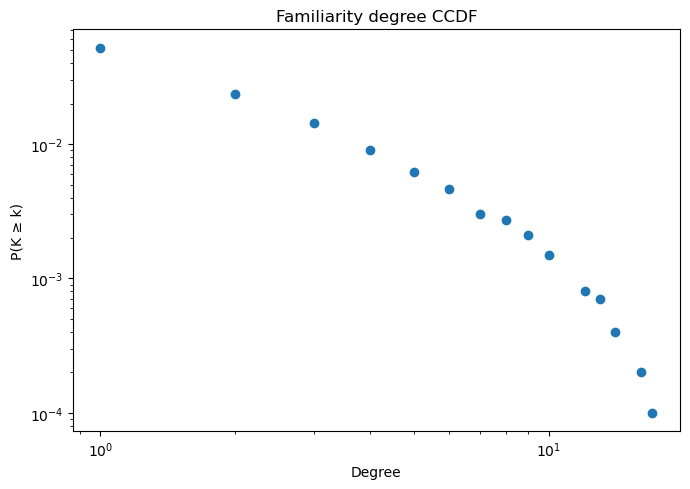

,rider_id,degree,degree_centrality,betweenness_centrality,closeness_centrality
49,R001533,13,0.220339,0.400327,0.373418
5,R000668,13,0.220339,0.354074,0.390728
53,R000778,10,0.169492,0.367531,0.393333
0,R007347,8,0.135593,0.207167,0.333333
16,R006081,7,0.118644,0.080674,0.287805
11,R002750,6,0.101695,0.093144,0.324176
13,R000471,6,0.101695,0.129077,0.341040
30,R004458,6,0.101695,0.302855,0.404110
3,R009901,6,0.101695,0.071408,0.302564
33,R002154,5,0.084746,0.024047,0.301020


In [13]:
dist = degree_distribution(graph, include_zero_degree=True)
plot_degree_ccdf(dist, title="Familiarity degree CCDF")
plt.show()

top = centrality_table(graph, use_gcc=True).sort_values("degree", ascending=False).head(10)
top


## Takeaway

Familiarity edges accumulate over the year; the GCC carries most path-length and centrality structure. Heavy-tailed degree and a modest social layer (see experiments notebook) motivate null and model comparisons.


## Activity tiers and co-attendance progression

From `longitudinal_metrics.csv` (baseline). Activity-tier assortativity reflects structural patterns partly driven by unequal attendance opportunities—not definitive social selection.


In [14]:
base = master[(master['scenario']=='baseline') & (master['seed']==6400)]
link = base[(base['network_type']=='familiarity') & (base['week'].isin([13,26,52]))]
cols = ['week','activity_tier_assortativity','mean_abs_baseline_rate_diff_on_edges',
        'share_familiar_of_coattending','share_social_of_coattending',
        'latent_repeated_co_not_social_dyads','latent_riders_with_co_but_no_social_tie']
link[[c for c in cols if c in link.columns]]


,week,activity_tier_assortativity,mean_abs_baseline_rate_diff_on_edges,share_familiar_of_coattending,share_social_of_coattending,latent_repeated_co_not_social_dyads,latent_riders_with_co_but_no_social_tie
6,13,NaN,72.300360,0.003596,0.000000,278.0,6107.0
8,26,-0.003344,76.197207,0.007059,0.000329,906.0,7596.0
12,52,-0.005044,73.976022,0.014969,0.000954,2752.0,8754.0


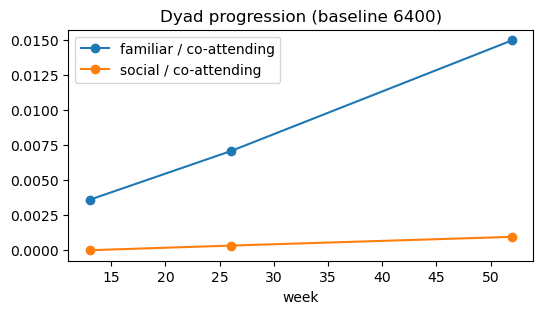

In [15]:
import matplotlib.pyplot as plt
if 'share_social_of_coattending' in link.columns:
    fig, ax = plt.subplots(figsize=(6,3))
    ax.plot(link['week'], link['share_familiar_of_coattending'], marker='o', label='familiar / co-attending')
    ax.plot(link['week'], link['share_social_of_coattending'], marker='o', label='social / co-attending')
    ax.set_xlabel('week'); ax.legend(); ax.set_title('Dyad progression (baseline 6400)'); plt.show()
